In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import warnings
import joblib
warnings.filterwarnings('ignore')



In [2]:
df=pd.read_csv("Telco_Customer_Churn (1).csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.MultipleLines.unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [7]:
df.InternetService.unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [8]:
df.Contract.unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [9]:
df.PaymentMethod.unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [10]:
df.DeviceProtection.unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [11]:
df.OnlineBackup.unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [12]:
df.OnlineSecurity.unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.shape

(7043, 21)

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA VISUALIZATION

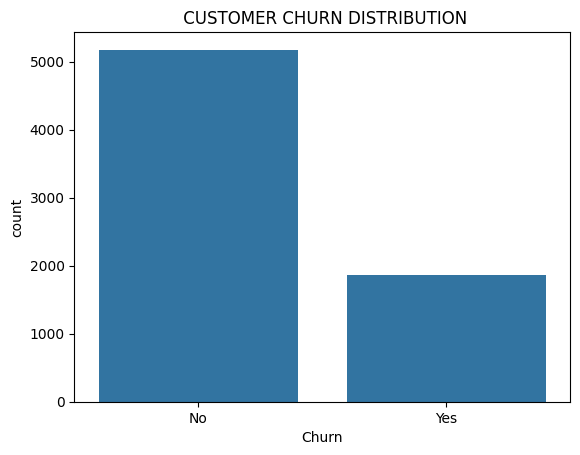

In [16]:
sns.countplot(x='Churn',data=df)
plt.title(" CUSTOMER CHURN DISTRIBUTION")
plt.show()

## FEATURE ENGINEERING

In [17]:
df.drop(['customerID'],axis=1,inplace=True)

## ENCODING

In [18]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']


bin_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']


cat_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaymentMethod']



In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in bin_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Initialize encoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform categorical columns
encoded = ohe.fit_transform(df[cat_cols])

# Convert back to DataFrame with proper column names
encoded_df = pd.DataFrame(encoded, 
                          columns=ohe.get_feature_names_out(cat_cols), 
                          index=df.index)

# Drop original categorical columns and join encoded ones
data = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)

In [21]:
print(data.shape)       # New shape after encoding
print(data.head(3))     # Preview first few rows

(7043, 41)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges TotalCharges Churn  ...  \
0                 1           29.85        29.85    No  ...   
1                 0           56.95       1889.5    No  ...   
2                 1           53.85       108.15   Yes  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 1.0                                  0.0   
1                 1.0                                  0.0   
2                 1.0                                  0.0   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                  0.0                      1.0                0.0   
1                  0.0                      0.0               

In [22]:
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [23]:
data['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
data['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [24]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [25]:
joblib.dump(scaler, "churn_scaler.joblib")
joblib.dump(le, "churn_label_encoder.joblib")
joblib.dump(ohe, "churn_onehot_encoder.joblib")


['churn_onehot_encoder.joblib']

In [26]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,No,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,No,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,1,53.85,108.15,Yes,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,42.30,1840.75,No,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,Yes,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   object 
 10  MultipleLines_No                         7043 no

In [28]:
data['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

### FEATURE SELECTION


In [29]:
y = data['Churn']
X = data.drop('Churn', axis=1)

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

### FEATURE SETS

In [31]:
fs_1 = [
    "tenure",
    "MonthlyCharges",
    "Contract_Month-to-month"
]

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

feature_importance_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

fs_2 = feature_importance_df.head(3)["Feature"].tolist()

print("FS_2:", fs_2)


FS_2: ['TotalCharges', 'tenure', 'MonthlyCharges']


In [33]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

fs_3 = mi_df.head(3)["Feature"].tolist()

print("FS_3 (Mutual Information):", fs_3)


FS_3 (Mutual Information): ['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No']


In [34]:
print(fs_1)
print(fs_2)
print(fs_3)

['tenure', 'MonthlyCharges', 'Contract_Month-to-month']
['TotalCharges', 'tenure', 'MonthlyCharges']
['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No']


In [35]:
feature_sets = {
    "FS_1": fs_1,
    "FS_2": fs_2,
    "FS_3": fs_3
}

### LOGISTIC REGRESSION

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score



================ FS_1 =================
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
ROC-AUC: 0.8223914335167531

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



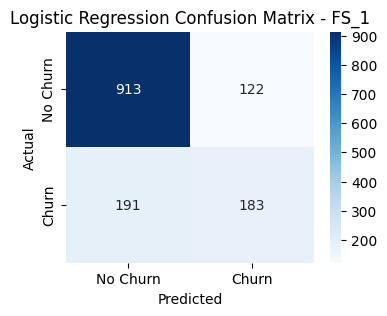


================ FS_2 =================
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
ROC-AUC: 0.8108062724431012

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1035
           1       0.61      0.42      0.50       374

    accuracy                           0.77      1409
   macro avg       0.71      0.66      0.68      1409
weighted avg       0.76      0.77      0.76      1409



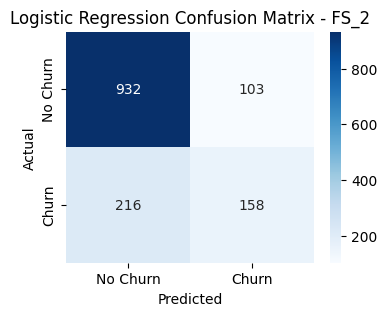


================ FS_3 =================
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
ROC-AUC: 0.8139515358185434

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.58      0.55      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



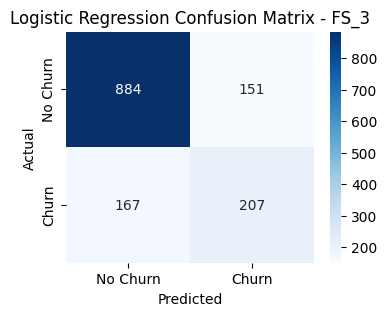

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

lr_results = []

# Logistic Regression hyperparameter grid
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # liblinear supports l1 and l2
}

for fs_name, features in feature_sets.items():
    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # Logistic Regression model
    lr = LogisticRegression(random_state=42, max_iter=1000)

    # Grid Search
    grid_lr = GridSearchCV(
        lr,
        lr_param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid_lr.fit(X_train, y_train)
    best_lr = grid_lr.best_estimator_

    # Predictions
    y_pred_lr = best_lr.predict(X_test)
    y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_lr)         
    print("Best Parameters:", grid_lr.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_lr))     
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_lr)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"Logistic Regression Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
    lr_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_lr.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_lr,
        "Classification Report": classification_report(y_test, y_pred_lr, output_dict=True)
    })


In [38]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

f1_score_lr = f1_score(y_test, y_pred_lr)
print("Logistic Regression F1 Score:", f1_score_lr)

Logistic Regression Accuracy: 0.7743080198722498
Logistic Regression F1 Score: 0.5655737704918032


###  RANDOM FOREST


================ FS_1 =================
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 100}
ROC-AUC: 0.8367485597664626

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



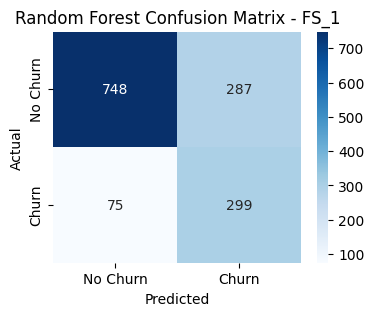


================ FS_2 =================
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 200}
ROC-AUC: 0.826013330233279

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.77      0.60       374

    accuracy                           0.73      1409
   macro avg       0.70      0.74      0.70      1409
weighted avg       0.79      0.73      0.75      1409



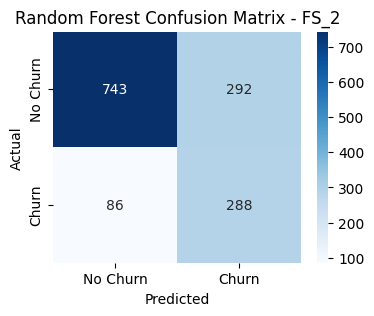


================ FS_3 =================
Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'n_estimators': 100}
ROC-AUC: 0.814388126792219

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1035
           1       0.47      0.82      0.60       374

    accuracy                           0.71      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.79      0.71      0.72      1409



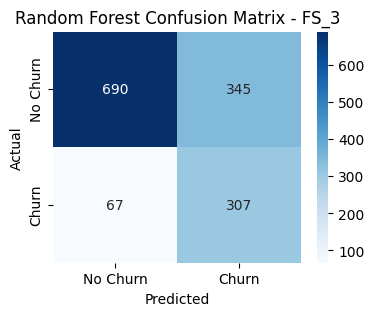

In [39]:
rf_results = []

for fs_name, features in feature_sets.items():

    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # Base model
    rf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced"   # VERY important for churn
    )

    param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "criterion": ['gini', 'entropy']   
}


    # Grid Search
    grid_rf = GridSearchCV(
        rf,
        param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_

    # Predictions
    y_pred_rf = best_rf.predict(X_test)
    y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_rf)

    print("Best Parameters:", grid_rf.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_rf))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_rf)

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"Random Forest Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    
   
    # Store results
    rf_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_rf.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_rf,
        "Classification Report": classification_report(y_test, y_pred_rf, output_dict=True)
 })
    

In [40]:

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

f1_score_rf = f1_score(y_test, y_pred_rf)
print("Random Forest F1 Score:", f1_score_rf)

Random Forest Accuracy: 0.7075940383250532
Random Forest F1 Score: 0.5984405458089669


### GRADIENT BOOSTING


================ FS_1 =================
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
ROC-AUC: 0.8313415484770983

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



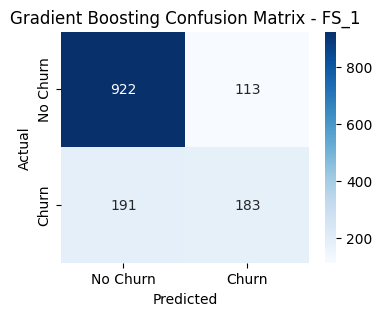


================ FS_2 =================
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
ROC-AUC: 0.82334470019892

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



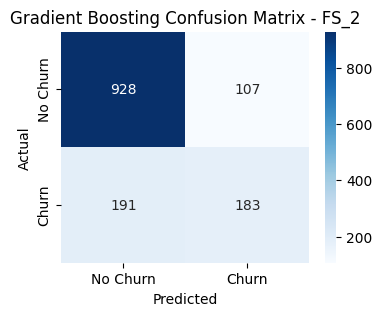


================ FS_3 =================
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
ROC-AUC: 0.8129582267689683

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.63      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.72      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



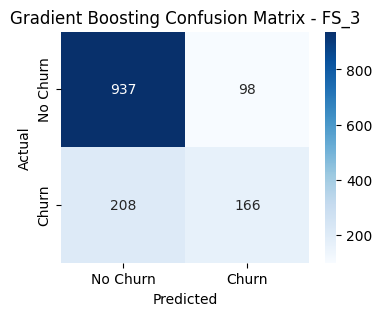

In [41]:
gb_results = []

for fs_name, features in feature_sets.items():

    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # Gradient Boosting model
    gb = GradientBoostingClassifier(random_state=42)


    gb_param_grid = {
    'n_estimators':[50,100],      # number of trees
    'learning_rate':[0.1, 0.2],    # step size shrinkage
    'max_depth':[3,5]         # depth of individual trees        
}
    # Grid Search
    grid_gb = GridSearchCV(
        gb,
        gb_param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid_gb.fit(X_train, y_train)

    best_gb = grid_gb.best_estimator_

    # Predictions
    y_pred_gb = best_gb.predict(X_test)
    y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_gb) 
    print("Best Parameters:", grid_gb.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_gb))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_gb)

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"Gradient Boosting Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

        # Store results
    gb_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_gb.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_gb,
        "Classification Report": classification_report(y_test, y_pred_gb, output_dict=True)
 })

    


In [42]:

accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)

f1_score_gb = f1_score(y_test, y_pred_gb)
print("Gradient Boosting F1 Score:", f1_score_gb)

Gradient Boosting Accuracy: 0.7828246983676366
Gradient Boosting F1 Score: 0.5203761755485894


### DESICION TREE


================ FS_1 =================
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
ROC-AUC: 0.8255586556098063

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.62      0.44      0.51       374

    accuracy                           0.78      1409
   macro avg       0.72      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



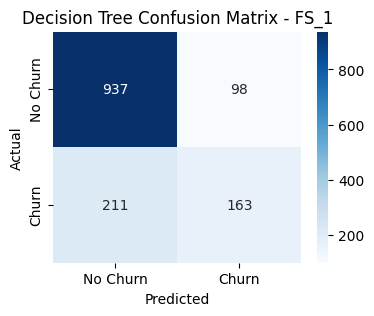


================ FS_2 =================
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
ROC-AUC: 0.8090017825311941

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1035
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.77      0.78      0.78      1409



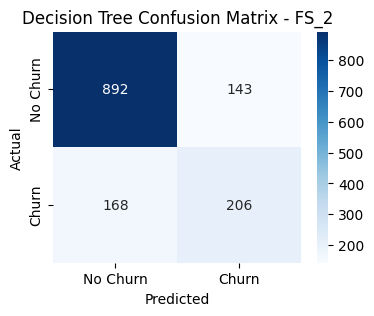


================ FS_3 =================
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
ROC-AUC: 0.8095610839856364

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



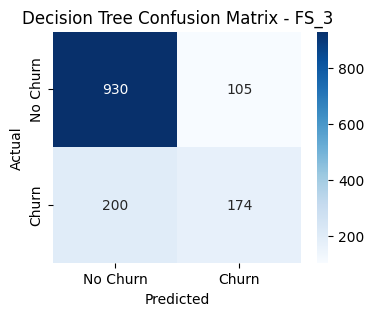

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dt_results = []

# Decision Tree hyperparameter grid
dt_param_grid = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

for fs_name, features in feature_sets.items():
    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # Decision Tree model
    dt = DecisionTreeClassifier(random_state=42)

    # Grid Search
    grid_dt = GridSearchCV(
        dt,
        dt_param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid_dt.fit(X_train, y_train)
    best_dt = grid_dt.best_estimator_

    # Predictions
    y_pred_dt = best_dt.predict(X_test)
    y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_dt)
    print("Best Parameters:", grid_dt.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_dt))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_dt)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"Decision Tree Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
        # Store results
    dt_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_dt.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_dt,
        "Classification Report": classification_report(y_test, y_pred_dt, output_dict=True)
 })


In [44]:


accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

f1_score_dt = f1_score(y_test, y_pred_dt)
print("Decision Tree F1 Score:", f1_score_dt)

Decision Tree Accuracy: 0.7835344215755855
Decision Tree F1 Score: 0.5329249617151608


### XG BOOSTING


================ FS_1 =================
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
ROC-AUC: 0.8344248107675218

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



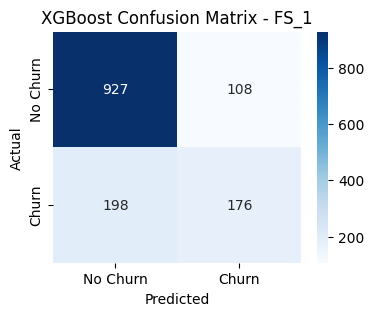


================ FS_2 =================
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
ROC-AUC: 0.8253933193830891

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1035
           1       0.65      0.42      0.51       374

    accuracy                           0.79      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.79      0.77      1409



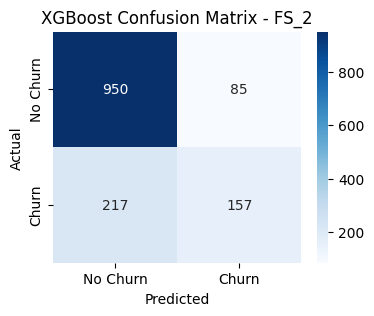


================ FS_3 =================
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
ROC-AUC: 0.8139037433155081

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.63      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.72      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



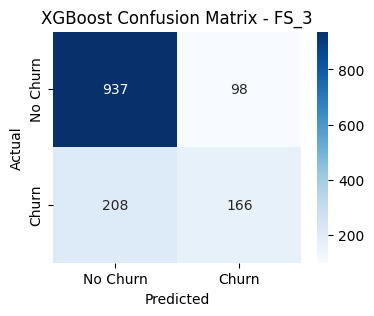

In [45]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

xgb_results = []

# XGBoost hyperparameter grid
xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

for fs_name, features in feature_sets.items():
    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # XGBoost model
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

    # Grid Search
    grid_xgb = GridSearchCV(
        xgb,
        xgb_param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid_xgb.fit(X_train, y_train)
    best_xgb = grid_xgb.best_estimator_

    # Predictions
    y_pred_xgb = best_xgb.predict(X_test)
    y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_xgb)    
    print("Best Parameters:", grid_xgb.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_xgb))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_xgb)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"XGBoost Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
    xgb_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_xgb.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_xgb,
        "Classification Report": classification_report(y_test, y_pred_xgb, output_dict=True)
    })


In [46]:

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

f1_score_xgb = f1_score(y_test, y_pred_xgb)
print("XGBoost F1 Score:", f1_score_xgb)

XGBoost Accuracy: 0.7828246983676366
XGBoost F1 Score: 0.5203761755485894


### SVM


================ FS_1 =================
SVM Parameters: {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True, 'random_state': 42}
ROC-AUC: 0.7694153814358418

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.93      0.86      1035
           1       0.67      0.38      0.49       374

    accuracy                           0.79      1409
   macro avg       0.74      0.66      0.68      1409
weighted avg       0.77      0.79      0.76      1409



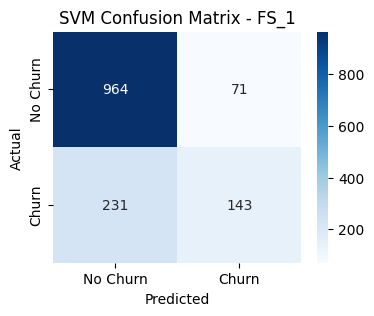


================ FS_2 =================
SVM Parameters: {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True, 'random_state': 42}
ROC-AUC: 0.7949701619778345

Classification Report:

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



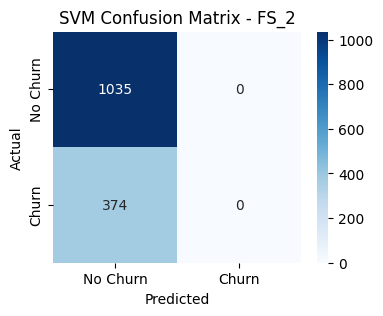


================ FS_3 =================
SVM Parameters: {'C': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True, 'random_state': 42}
ROC-AUC: 0.7511547702084787

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.58      0.45      0.51       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.75      0.77      0.76      1409



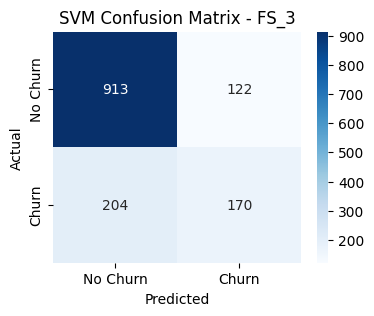

In [47]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

svm_results = []

# Choose hyperparameters manually
svm_params = {
    'C': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'probability': True,  # needed for predict_proba
    'random_state': 42
}

for fs_name, features in feature_sets.items():
    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # SVM model
    svm = SVC(**svm_params)
    svm.fit(X_train, y_train)

    # Predictions
    y_pred_svm = svm.predict(X_test)
    y_proba_svm = svm.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_svm)
    print("SVM Parameters:", svm_params)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_svm))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_svm)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"SVM Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
        # Store results
    svm_results.append({
        "Feature Set": fs_name,
        "Params": svm_params,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_svm,
        "Classification Report": classification_report(y_test, y_pred_svm, output_dict=True)
 })
    

In [48]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

f1_score_svm = f1_score(y_test, y_pred_svm)
print("SVM F1 Score:", f1_score_svm)

SVM Accuracy: 0.7686302342086586
SVM F1 Score: 0.5105105105105106


### ADA BOOSTING


================ FS_1 =================
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 100}
ROC-AUC: 0.8264912552636338

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.95      0.86      1035
           1       0.67      0.31      0.42       374

    accuracy                           0.78      1409
   macro avg       0.73      0.63      0.64      1409
weighted avg       0.76      0.78      0.75      1409



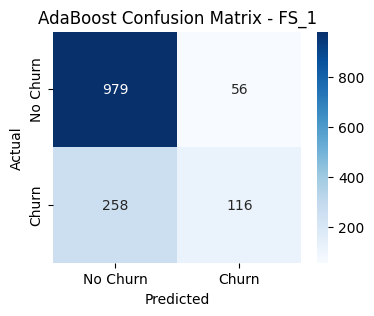


================ FS_2 =================
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 100}
ROC-AUC: 0.8163876617840812

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.97      0.86      1035
           1       0.74      0.25      0.37       374

    accuracy                           0.78      1409
   macro avg       0.76      0.61      0.62      1409
weighted avg       0.77      0.78      0.73      1409



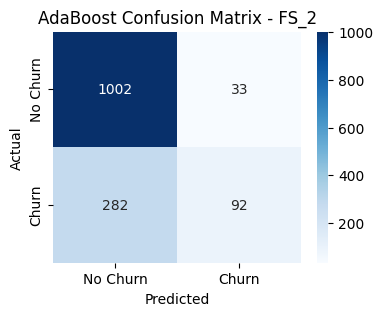


================ FS_3 =================
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 100}
ROC-AUC: 0.8108682735281201

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.94      0.87      1035
           1       0.70      0.36      0.48       374

    accuracy                           0.79      1409
   macro avg       0.75      0.65      0.67      1409
weighted avg       0.78      0.79      0.77      1409



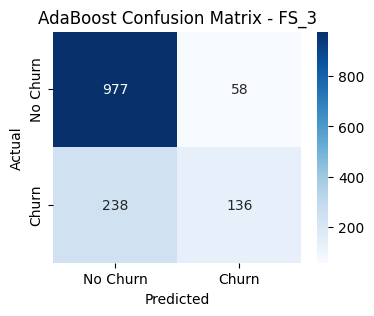

In [49]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

ada_results = []

# AdaBoost hyperparameter grid
ada_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'algorithm': ['SAMME', 'SAMME.R']
}

for fs_name, features in feature_sets.items():
    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # AdaBoost model
    ada = AdaBoostClassifier(random_state=42)

    # Grid Search
    grid_ada = GridSearchCV(
        ada,
        ada_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )

    grid_ada.fit(X_train, y_train)
    best_ada = grid_ada.best_estimator_

    # Predictions
    y_pred_ada = best_ada.predict(X_test)
    y_proba_ada = best_ada.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_ada)
    print("Best Parameters:", grid_ada.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_ada))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_ada)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"AdaBoost Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
        # Store results
    ada_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_ada.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_ada,
        "Classification Report": classification_report(y_test, y_pred_ada, output_dict=True)
 })

In [50]:

accuracy_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", accuracy_ada)

f1_score_ada = f1_score(y_test, y_pred_ada)
print("AdaBoost F1 Score:", f1_score_ada)

AdaBoost Accuracy: 0.7899219304471257
AdaBoost F1 Score: 0.4788732394366197


### KNN


================ FS_1 =================
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
ROC-AUC: 0.7833074995479088

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1035
           1       0.57      0.47      0.51       374

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.76      1409



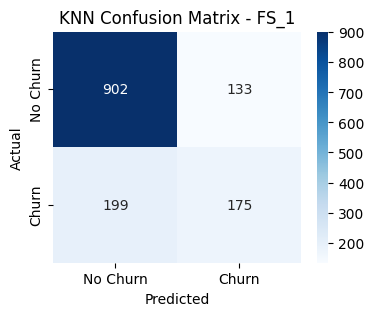


================ FS_2 =================
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
ROC-AUC: 0.7782931617969981

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.64      0.44      0.52       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409



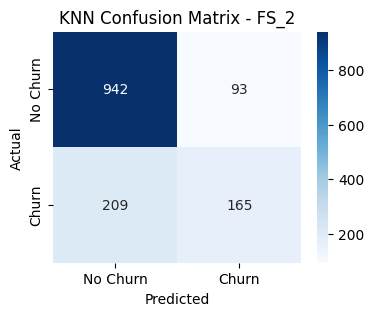


================ FS_3 =================
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
ROC-AUC: 0.7371916091864941

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1035
           1       0.51      0.35      0.41       374

    accuracy                           0.74      1409
   macro avg       0.65      0.61      0.62      1409
weighted avg       0.71      0.74      0.72      1409



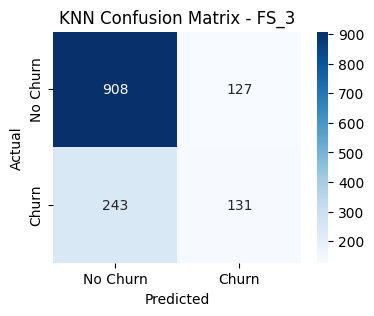

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

knn_results = []

# KNN hyperparameter grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7,9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

for fs_name, features in feature_sets.items():
    print(f"\n================ {fs_name} =================")

    # Select features
    X_fs = X[features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_fs, y, test_size=0.2, random_state=42, stratify=y
    )

    # KNN model
    knn = KNeighborsClassifier()

    # Grid Search
    grid_knn = GridSearchCV(
        knn,
        knn_param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid_knn.fit(X_train, y_train)
    best_knn = grid_knn.best_estimator_

    # Predictions
    y_pred_knn = best_knn.predict(X_test)
    y_proba_knn = best_knn.predict_proba(X_test)[:, 1]

    # Metrics
    auc = roc_auc_score(y_test, y_proba_knn)
    print("Best Parameters:", grid_knn.best_params_)
    print("ROC-AUC:", auc)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_knn))
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_knn)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"KNN Confusion Matrix - {fs_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
        # Store results
    knn_results.append({
        "Feature Set": fs_name,
        "Best Params": grid_knn.best_params_,
        "ROC-AUC": auc,
        "y_test": y_test,
        "y_prob": y_proba_knn,
        "Classification Report": classification_report(y_test, y_pred_knn, output_dict=True)
 })
    


In [52]:

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)
f1_score_knn = f1_score(y_test, y_pred_knn)
print("KNN F1 Score:", f1_score_knn)

KNN Accuracy: 0.7374024130589071
KNN F1 Score: 0.41455696202531644


### COMBINED RESULTS 

In [53]:
import pandas as pd
from sklearn.metrics import classification_report


# Combine all results into a dictionary
algorithms_results = {
    "Gradient Boosting": gb_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
    "SVM": svm_results,
    "AdaBoost": ada_results,
    "KNN": knn_results,
    "Logistic Regression": lr_results
}

combined_results = []

for algo_name, results in algorithms_results.items():
    for res in results:
        y_test = res.get("y_test")
        y_proba = res.get("y_prob")
        class_report = res.get("Classification Report", None)

        # Default threshold metrics (0.5)
        if class_report is not None:
            precision = class_report['1']['precision']
            recall = class_report['1']['recall']
            f1 = class_report['1']['f1-score']
            accuracy = class_report['accuracy']
        else:
            precision = recall = f1 = accuracy = None

        # Custom threshold metrics
        if y_proba is not None and y_test is not None:
            y_pred_custom = (y_proba >= 0.5).astype(int)
            class_report_custom = classification_report(y_test, y_pred_custom, output_dict=True)
            precision_custom = class_report_custom['1']['precision']
            recall_custom = class_report_custom['1']['recall']
            f1_custom = class_report_custom['1']['f1-score']
            accuracy_custom = class_report_custom['accuracy']
        else:
            precision_custom = recall_custom = f1_custom = accuracy_custom = None

        combined_results.append({
            "Algorithm": algo_name,
            "Feature Set": res.get("Feature Set"),
            "Best Params": res.get("Best Params") or res.get("Params"),
            "ROC-AUC": res.get("ROC-AUC"),
            "Accuracy": accuracy,
            "Precision (Churn)": precision,
            "Recall (Churn)": recall,
            "F1-Score (Churn)": f1,
            
        })

# Convert to DataFrame
df_results = pd.DataFrame(combined_results)

# Sort by ROC-AUC descending
df_results = df_results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# Display the full table
print(df_results)


              Algorithm Feature Set  \
0         Random Forest        FS_1   
1               XGBoost        FS_1   
2     Gradient Boosting        FS_1   
3              AdaBoost        FS_1   
4         Random Forest        FS_2   
5         Decision Tree        FS_1   
6               XGBoost        FS_2   
7     Gradient Boosting        FS_2   
8   Logistic Regression        FS_1   
9              AdaBoost        FS_2   
10        Random Forest        FS_3   
11  Logistic Regression        FS_3   
12              XGBoost        FS_3   
13    Gradient Boosting        FS_3   
14             AdaBoost        FS_3   
15  Logistic Regression        FS_2   
16        Decision Tree        FS_3   
17        Decision Tree        FS_2   
18                  SVM        FS_2   
19                  KNN        FS_1   
20                  KNN        FS_2   
21                  SVM        FS_1   
22                  SVM        FS_3   
23                  KNN        FS_3   

                        

In [54]:
print(df_results.columns)


Index(['Algorithm', 'Feature Set', 'Best Params', 'ROC-AUC', 'Accuracy',
       'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)'],
      dtype='object')


In [55]:
best_overall_auc_df = (
    df_results
    .loc[[df_results['ROC-AUC'].idxmax()],
         ['Algorithm', 'Feature Set', 'ROC-AUC', 'F1-Score (Churn)']]
    .reset_index(drop=True)
)

best_overall_auc_df


,Algorithm,Feature Set,ROC-AUC,F1-Score (Churn)
0,Random Forest,FS_1,0.836749,0.622917


In [56]:
best_per_fs_auc_df = (
    df_results
    .loc[df_results.groupby('Feature Set')['ROC-AUC'].idxmax(),
         ['Feature Set', 'Algorithm', 'ROC-AUC', 'F1-Score (Churn)']]
    .reset_index(drop=True)
)

best_per_fs_auc_df


,Feature Set,Algorithm,ROC-AUC,F1-Score (Churn)
0,FS_1,Random Forest,0.836749,0.622917
1,FS_2,Random Forest,0.826013,0.603774
2,FS_3,Random Forest,0.814388,0.598441


In [57]:
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score

# Logistic Regression
y_pred_lr = grid_lr.predict(X_test)
y_proba_lr = grid_lr.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_score_lr = f1_score(y_test, y_pred_lr)
logloss_lr = log_loss(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Random Forest
y_pred_rf = grid_rf.predict(X_test)
y_proba_rf = grid_rf.predict_proba(X_test)[:, 1]
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)
logloss_rf = log_loss(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Gradient Boosting
y_pred_gb = grid_gb.predict(X_test)
y_proba_gb = grid_gb.predict_proba(X_test)[:, 1]
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_score_gb = f1_score(y_test, y_pred_gb)
logloss_gb = log_loss(y_test, y_proba_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)

# Decision Tree
y_pred_dt = grid_dt.predict(X_test)
y_proba_dt = grid_dt.predict_proba(X_test)[:, 1]
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_score_dt = f1_score(y_test, y_pred_dt)
logloss_dt = log_loss(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

# K-Nearest Neighbors
y_pred_knn = grid_knn.predict(X_test)
y_proba_knn = grid_knn.predict_proba(X_test)[:, 1]
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_score_knn = f1_score(y_test, y_pred_knn)
logloss_knn = log_loss(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)    

# SVM
y_pred_svm = svm.predict(X_test)          
y_proba_svm = svm.decision_function(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_score_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)
    
# ADA Boosting
y_pred_ada = grid_ada.predict(X_test)
y_proba_ada = grid_ada.predict_proba(X_test)[:, 1]
accuracy_ada = accuracy_score(y_test, y_pred_ada)
f1_score_ada = f1_score(y_test, y_pred_ada)
logloss_ada = log_loss(y_test, y_proba_ada)
auc_ada = roc_auc_score(y_test, y_proba_ada)    

# XGBoost
y_pred_xgb = grid_xgb.predict(X_test)
y_proba_xgb = grid_xgb.predict_proba(X_test)[:, 1]
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_score_xgb = f1_score(y_test, y_pred_xgb)
logloss_xgb = log_loss(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)    


In [58]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Random Forest", "Gradient Boosting",
        "Decision Tree", "SVM", "KNN", "XGBoost", "AdaBoost"
    ],
    "Accuracy": [
        accuracy_lr, accuracy_rf, accuracy_gb,
        accuracy_dt, accuracy_svm, accuracy_knn,
        accuracy_xgb, accuracy_ada
    ],
    "AUC": [
        auc_lr, auc_rf, auc_gb,
        auc_dt, auc_svm, auc_knn,
        auc_xgb, auc_ada
    ],
    "F1 Score": [
        f1_score_lr, f1_score_rf, f1_score_gb,
        f1_score_dt, f1_score_svm, f1_score_knn,
        f1_score_xgb, f1_score_ada
    ],
   
})

results


,Model,Accuracy,AUC,F1 Score
0,Logistic Regression,0.774308,0.813952,0.565574
1,Random Forest,0.707594,0.814388,0.598441
2,Gradient Boosting,0.782825,0.812958,0.520376
3,Decision Tree,0.783534,0.809561,0.532925
4,SVM,0.768630,0.751139,0.510511
5,KNN,0.737402,0.737192,0.414557
6,XGBoost,0.782825,0.813904,0.520376
7,AdaBoost,0.789922,0.810868,0.478873


In [59]:
#Identify the model with the best AUC

best_auc = results.loc[results['AUC'].idxmax()]
best_auc


Model       Random Forest
Accuracy         0.707594
AUC              0.814388
F1 Score         0.598441
Name: 1, dtype: object

In [60]:
#Identify the model with the best F1 Score
best_f1 = results.loc[results['F1 Score'].idxmax()]
best_f1


Model       Random Forest
Accuracy         0.707594
AUC              0.814388
F1 Score         0.598441
Name: 1, dtype: object

### COMPARING WHICH ALGORITHM IS BEST USING AUC & F1_SCORE

In [61]:
results['Rank_AUC'] = results['AUC'].rank(ascending=False)
results['Rank_F1'] = results['F1 Score'].rank(ascending=False)

results['Avg_Rank'] = (results['Rank_AUC'] + results['Rank_F1']) / 2

results.sort_values('Avg_Rank')


,Model,Accuracy,AUC,F1 Score,Rank_AUC,Rank_F1,Avg_Rank
1,Random Forest,0.707594,0.814388,0.598441,1.0,1.0,1.00
0,Logistic Regression,0.774308,0.813952,0.565574,2.0,2.0,2.00
6,XGBoost,0.782825,0.813904,0.520376,3.0,4.5,3.75
2,Gradient Boosting,0.782825,0.812958,0.520376,4.0,4.5,4.25
3,Decision Tree,0.783534,0.809561,0.532925,6.0,3.0,4.50
7,AdaBoost,0.789922,0.810868,0.478873,5.0,7.0,6.00
4,SVM,0.768630,0.751139,0.510511,7.0,6.0,6.50
5,KNN,0.737402,0.737192,0.414557,8.0,8.0,8.00


In [62]:
best_models = pd.concat([
    best_auc.to_frame().T.assign(Selection="Best by ROC-AUC"),
    best_f1.to_frame().T.assign(Selection="Best by F1-Score")
], ignore_index=True)

best_models


,Model,Accuracy,AUC,F1 Score,Selection
0,Random Forest,0.707594,0.814388,0.598441,Best by ROC-AUC
1,Random Forest,0.707594,0.814388,0.598441,Best by F1-Score


In [63]:
import joblib

joblib.dump(grid_lr, "churn_lr_model.joblib")
joblib.dump(X.columns, "lr_model_features.joblib")


joblib.dump(grid_rf, "churn_rf_model.joblib")
joblib.dump(X.columns, "rf_model_features.joblib")

joblib.dump(grid_gb, "churn_gb_model.joblib")
joblib.dump(X.columns, "gb_model_features.joblib")


joblib.dump(grid_dt, "churn_dt_model.joblib")
joblib.dump(X.columns, "dt_model_features.joblib")


joblib.dump(grid_xgb, "churn_xgb_model.joblib")
joblib.dump(X.columns, "xgb_model_features.joblib")


joblib.dump(svm, "churn_svm_model.joblib")
joblib.dump(X.columns, "svm_model_features.joblib")


joblib.dump(grid_ada, "churn_ada_model.joblib")
joblib.dump(X.columns, "ada_model_features.joblib")


joblib.dump(grid_knn, "churn_knn_model.joblib")
joblib.dump(X.columns, "knn_model_features.joblib")

['knn_model_features.joblib']

In [64]:
results_df = pd.DataFrame(results)

# Optional: sort by F1 score (recommended)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df.to_excel(
    "Churn_Model_Comparison.xlsx",
    index=False
)


In [65]:
results_df = pd.DataFrame(results)

# Optional: sort by F1 score (recommended)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df.to_csv(
    "Churn_Model_Comparison.csv",
    index=False
)